### Подготовка данных

In [24]:
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-writing-paper-sales.csv"
time_series = pd.read_csv(url)

time_series.sample(5)

,Month,Sales
130,11-11,2912.490
105,9-10,1798.615
10,1-11,1221.370
26,3-03,1761.095
39,4-04,1648.535


,Month,Sales
136,12-05,2640.470
65,6-06,1749.370
81,7-10,2061.255
90,8-07,1571.150
55,5-08,581.560


In [25]:
len(time_series)

147

147

In [26]:
time_series.isnull().sum()

,0
Month,0
Sales,0


,0
Month,0
Sales,0


In [27]:
time_series.dtypes

,0
Month,object
Sales,float64


,0
Month,object
Sales,float64


In [28]:
#time_series['Month'] = pd.to_datetime(time_series['Month'])
time_series['Month'] = time_series['Month'].apply(
    lambda s: pd.Timestamp(year=1900 + int(s.split('-')[0]),
                           month=int(s.split('-')[1]),
                           day=1)
)
time_series.set_index('Month', inplace=True)

In [29]:
time_series.dtypes

,0
Sales,float64


,0
Sales,float64


In [30]:
time_series.sample(5)

,Sales
Month,
1902-02-01,1486.730
1906-09-01,1671.985
1909-06-01,2305.135
1908-11-01,1639.155
1903-11-01,1730.610


,Sales
Month,
1903-04-01,1632.120
1907-09-01,1627.430
1902-05-01,1489.075
1901-11-01,1221.370
1903-02-01,1531.285


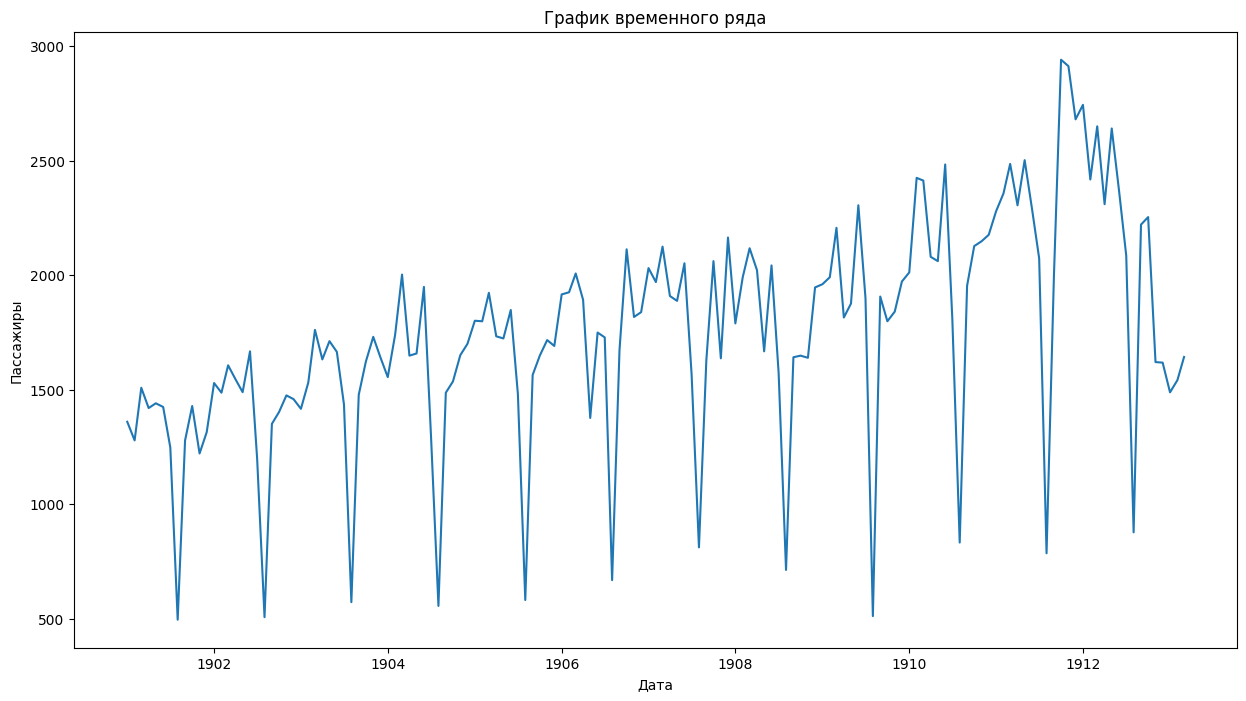

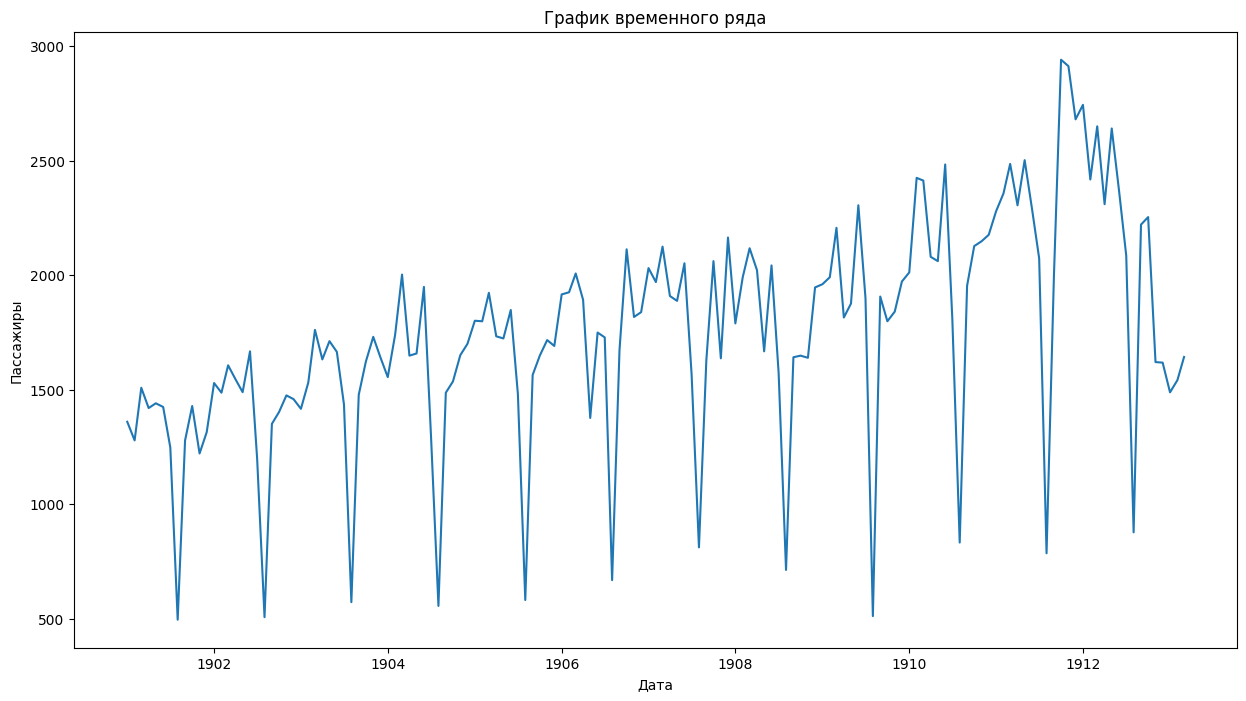

In [31]:
plt.figure(figsize=(15,8))
plt.plot(time_series['Sales'])
plt.title('График временного ряда')
plt.xlabel('Дата')
plt.ylabel('Пассажиры')
plt.show()

In [32]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [33]:
train, test = train_test_split(time_series, test_size=0.2, shuffle=False)

In [34]:
train.shape

(117, 1)

(117, 1)

In [35]:
test.shape

(30, 1)

(30, 1)

In [36]:
test.head()

,Sales
Month,
1910-10-01,2126.915
1910-11-01,2148.020
1910-12-01,2176.160
1911-01-01,2279.340
1911-02-01,2356.725


,Sales
Month,
1910-10-01,2126.915
1910-11-01,2148.020
1910-12-01,2176.160
1911-01-01,2279.340
1911-02-01,2356.725


### Обучение модели

In [37]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

class MLARWrapper:
    """
    Обучает ML‑модель на лагах и эмулирует интерфейс statsmodels ARIMA:
    - resid   (остатки на обучающей выборке)
    - forecast(steps)
    - simulate(nsimulations, anchor='end', repetitions=1, random_errors=None)
    """
    def __init__(self, model, lags=12):
        """
        model : объект sklearn‑регрессора (например, RandomForestRegressor)
        lags  : количество запаздывающих наблюдений (p)
        """
        self.model = model
        self.lags = lags

    def fit(self, train_series):
        """
        train_series : pd.Series или np.array – одномерный временной ряд
        """
        y = train_series.values.reshape(-1, 1) if isinstance(train_series, pd.Series) else train_series
        X, y_target = self._build_lags(y, self.lags)
        self.model.fit(X, y_target)

        # Сохраняем ряд для дальнейшего прогнозирования
        self._fitted_series = y.ravel()
        # Вычисляем остатки на обучении
        y_pred = self.model.predict(X)
        self.resid = y_target - y_pred          # атрибут, как у ARIMA
        self._last_vals = y[-self.lags:].ravel() # последние известные значения
        return self

    def _build_lags(self, y, p):
        """Строит матрицу лагов и целевой вектор."""
        n = len(y)
        X = np.zeros((n-p, p))
        for i in range(p, n):
            X[i-p] = y[i-p:i].ravel()
        y_target = y[p:].ravel()
        return X, y_target

    def predict(self, X):
        """Предсказание по матрице признаков (лагов)."""
        return self.model.predict(X)

    def forecast(self, steps):
        """Рекурсивный точечный прогноз на 'steps' шагов."""
        forecast_vals = np.zeros(steps)
        last_vals = self._last_vals.copy()  # стартовый вектор лагов
        for i in range(steps):
            pred = self.model.predict(last_vals.reshape(1, -1))[0]
            forecast_vals[i] = pred
            # сдвигаем лаги: добавляем новый прогноз
            last_vals = np.append(last_vals[1:], pred)
        return forecast_vals

    def simulate(self, nsimulations, anchor='end', repetitions=1, random_errors=None):
        """
        Симуляция будущих значений с возможность передачи пользовательских ошибок.
        random_errors : np.array формы (steps,) или (steps,1) – шум, добавляемый после predict.
        """
        # В данный момент repetitions не используется, можно игнорировать
        steps = nsimulations
        sim_vals = np.zeros(steps)
        last_vals = self._last_vals.copy()
        errors = random_errors.ravel() if random_errors is not None else np.zeros(steps)
        for i in range(steps):
            pred = self.model.predict(last_vals.reshape(1, -1))[0]
            sim_vals[i] = pred + errors[i]
            # обновляем лаги
            last_vals = np.append(last_vals[1:], sim_vals[i])
        return sim_vals

In [38]:
!pip install catboost

In [39]:
from catboost import CatBoostRegressor

ml_model = MLARWrapper(
    model=CatBoostRegressor(
        iterations=300,
        learning_rate=0.1,
        depth=5,
        l2_leaf_reg=5, # без регуляризации интервалы поулчаются совсем узкие
        random_seed=42,
        verbose=0
    ),
    lags=12)

fitted_model = ml_model.fit(train['Sales'])

### Реализации бутстрапа

In [40]:
def residual_bootstrap(fitted_model, steps, n_bootstrap=1000):
    residuals = fitted_model.resid
    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = np.random.choice(residuals, size=steps, replace=True)
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [41]:
# max - половина максимальной ошибки
# mean - половина средней ошибки
# median - половина медианной ошибки
def naive_bootstraps(fitted_model, steps, method, n_bootstrap=1000):
    residuals = fitted_model.resid
    abs_resids = np.abs(residuals)

    if method == 'max':
        error_magnitude = np.max(abs_resids) / 2.0
        # Равномерное распределение на [-mag, mag]
        sampler = lambda: np.random.uniform(-error_magnitude, error_magnitude, size=steps)
    elif method == 'mean':
        error_magnitude = np.mean(abs_resids) / 2.0
        # Нормальное распределение со стандартным отклонением = mag
        sampler = lambda: np.random.normal(0, error_magnitude, size=steps)
    elif method == 'median':
        error_magnitude = np.median(abs_resids) / 2.0
        sampler = lambda: np.random.normal(0, error_magnitude, size=steps)
    else:
        raise ValueError("[naive] no such method ")

    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = sampler()                     # случайный шум
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [42]:
!pip install arch

import arch
from arch.bootstrap import MovingBlockBootstrap

def arch_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000):
    residuals = fitted_model.resid
    point_forecast = fitted_model.forecast(steps=steps)

    mbb = MovingBlockBootstrap(block_length, residuals)
    forecasts = []

    for data in mbb.bootstrap(n_bootstrap):
        # data[0][0] содержит сгенерированный ряд остатков
        boot_resid = data[0][0]

        if len(boot_resid) >= steps:
            boot_forecast = point_forecast + boot_resid[:steps]
            forecasts.append(boot_forecast)
        else:
            # Если остатков не хватает, повторяем их циклически
            repeated_resid = np.tile(boot_resid, int(np.ceil(steps / len(boot_resid))))[:steps]
            boot_forecast = point_forecast + repeated_resid
            forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)

    return lower, upper, forecasts

In [43]:
!pip install tsbootstrap

from tsbootstrap import WholeSieveBootstrap

def sieve_bootstrap(fitted_model, steps, min_lag=1, max_lag=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid

    centered_resid = residuals - np.mean(residuals)

    sieve = WholeSieveBootstrap(n_bootstraps=n_bootstrap)

    boot_residuals = sieve.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [44]:
from tsbootstrap import MovingBlockBootstrap as tsbootstrap_mbb

def tsbootstrap_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid

    centered_resid = residuals - np.mean(residuals)

    mbb = tsbootstrap_mbb(n_bootstraps=n_bootstrap, rng=random_state, block_length=block_length)

    boot_residuals = mbb.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

### Сравнение методов

In [45]:
def evaluate(true_values, lower, upper):
    true_vals = np.array(true_values).flatten()

    # доля истинных значений, попавших в интервал
    coverage = np.mean((lower <= true_vals[:len(lower)]) & (true_vals[:len(lower)] <= upper))

    # средняя ширина интервала
    avg_width = np.mean(upper - lower)
    return coverage, avg_width

forecast_steps = 24
forecast = fitted_model.forecast(steps=forecast_steps)

test_values = test.values.flatten()[:forecast_steps]

results = {}

# Residual Bootstrap
try:
    lower_res_c, upper_res_c, all_forecasts_res_c  = residual_bootstrap(fitted_model, forecast_steps)
    coverage_res_c, width_res_c = evaluate(test_values, lower_res_c, upper_res_c)
    results['Residual Bootstrap Correct'] = {'coverage': coverage_res_c, 'width': width_res_c, 'lower': lower_res_c, 'upper': upper_res_c}
    print("Residual Bootstrap Correct - OK")
except Exception as e:
    print(f"Residual Bootstrap Correct error: {e}")

# Naive
try:
    for method in ["max", "mean", "median"]:
        lower_naive, upper_naive, all_forecasts_naive  = naive_bootstraps(fitted_model, forecast_steps, method)
        coverage_naive, width_naive = evaluate(test_values, lower_naive, upper_naive)
        results['Naive-' + method] = {'coverage': coverage_naive, 'width': width_naive, 'lower': lower_naive, 'upper': upper_naive}
        print(f" ### Naive {method} - OK")
    print("Naive - OK")
except Exception as e:
    print(f"Naive: {e}")

# ARCH block Bootstrap
try:
    lower_arch, upper_arch, _ = arch_block_bootstrap(fitted_model, forecast_steps, block_length=12)
    coverage_arch, width_arch = evaluate(test_values, lower_arch, upper_arch)
    results['ARCH Block Bootstrap'] = {'coverage': coverage_arch, 'width': width_arch, 'lower': lower_arch, 'upper': upper_arch}
    print("ARCH Block Bootstrap - OK")
except Exception as e:
    print(f"ARCH Block Bootstrap error: {e}")

# Sieve bootstrap
try:
    lower_sieve, upper_sieve, _ = sieve_bootstrap(fitted_model, forecast_steps)
    coverage_sieve, width_sieve = evaluate(test_values, lower_sieve, upper_sieve)
    results['Sieve Bootstrap'] = {'coverage': coverage_sieve, 'width': width_sieve, 'lower': lower_sieve, 'upper': upper_sieve}
    print("Sieve Bootstrap - OK")
except Exception as e:
    print(f"Sieve Bootstrap error: {e}")

# tsbootstrap block bootstrap
try:
    lower_block, upper_block, _ = tsbootstrap_block_bootstrap(fitted_model, forecast_steps)
    coverage_block, width_block = evaluate(test_values, lower_block, upper_block)
    results['Tsbootstrap Block Bootstrap'] = {'coverage': coverage_block, 'width': width_block, 'lower': lower_block, 'upper': upper_block}
    print("Tsbootstrap Block Bootstrap - OK")
except Exception as e:
    print(f"Tsbootstrap Block Bootstrap error: {e}")

results_df = pd.DataFrame(results).T[['coverage', 'width']]
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)
print(results_df)

Residual Bootstrap Correct - OK
 ### Naive max - OK
 ### Naive mean - OK
 ### Naive median - OK
Naive - OK
ARCH Block Bootstrap - OK
[ 2.11931789e+01 -5.50243541e+00  9.95775193e+00 -7.33760873e+00
 -2.13052711e+01  2.27830327e+01 -2.40850356e+01 -1.76840048e+01
 -1.83428086e+01 -1.16933391e+01  1.16611015e+01  2.29943016e+00
 -2.63037875e+01 -9.77999943e+00  1.44533088e+01  9.79525354e+00
  2.27520089e+01 -1.58178862e+01  2.12652212e+01 -4.77785500e+00
  7.58649985e+00  2.24556698e+01  2.52359527e+01  1.14769489e+01
 -1.77232283e+01  1.32693998e+01  2.46338143e+01 -8.46008856e+00
 -4.44395987e-01  2.59440540e+01 -3.30670388e+01  1.06130048e+01
 -2.04339893e+01 -1.22540411e+01 -1.04829885e+01 -4.27007960e+00
  1.30008397e+01 -2.26862937e+01 -2.02404776e+01 -8.01484174e+00
  1.02964534e+01 -7.14405624e+00  1.20516791e+01 -6.77947985e+00
 -4.52900383e+00 -1.47817906e+01 -6.96043756e+00 -2.92536325e+01
  1.20517590e+01  1.34447361e+01  2.34936768e+00  1.23100103e+01
 -5.71526835e+01 -1.78

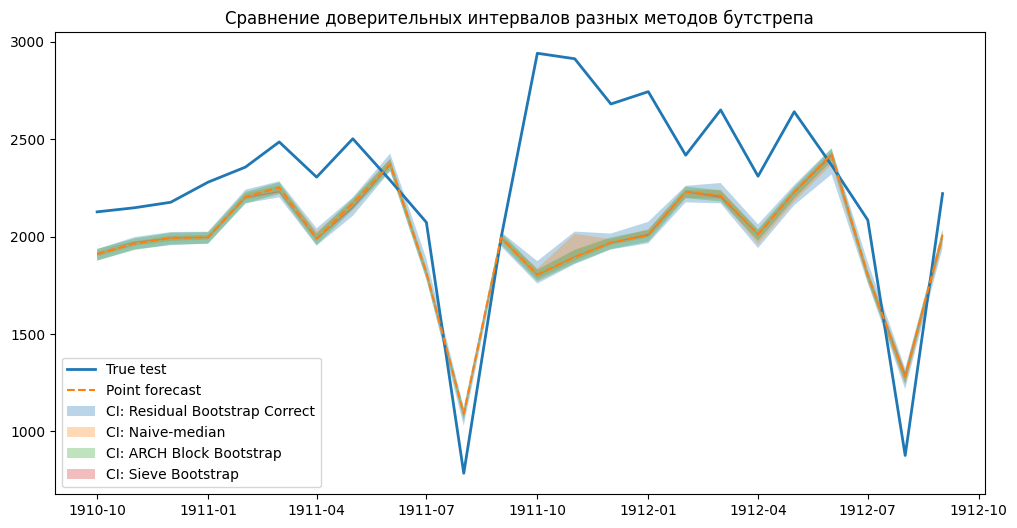

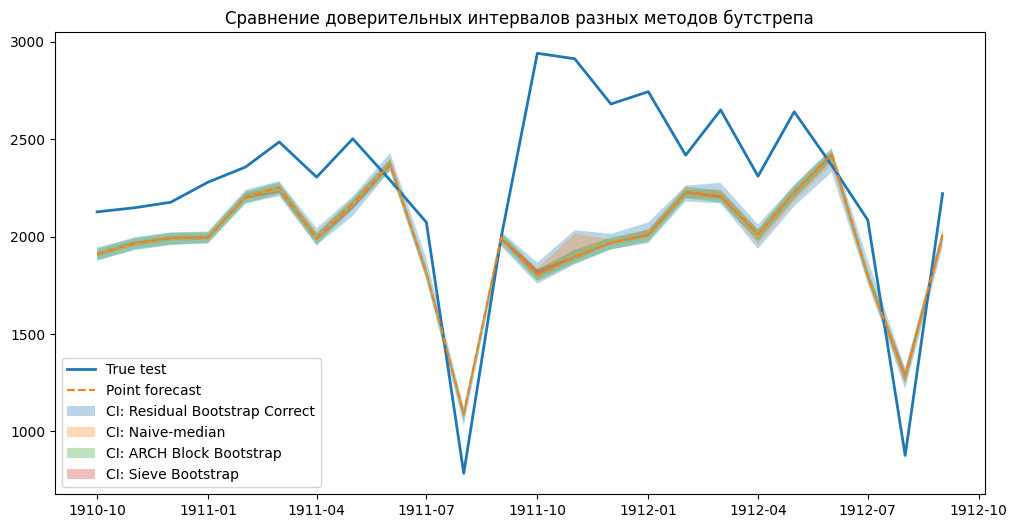

In [46]:
plt.figure(figsize=(12,6))
plt.plot(test.index[:forecast_steps], test_values, label='True test', linewidth=2)
plt.plot(test.index[:forecast_steps], forecast[:forecast_steps], label='Point forecast', linestyle='--')

to_plot = ['Residual Bootstrap Correct', 'Naive-median', 'ARCH Block Bootstrap', 'Sieve Bootstrap']

for name in results.keys():
    if name not in to_plot:
        continue

    lower = results[name]['lower']
    upper = results[name]['upper']

    plt.fill_between(test.index[:forecast_steps], lower, upper, alpha=0.3, label=f'CI: {name}')

plt.legend()
plt.title('Сравнение доверительных интервалов разных методов бутстрепа')
plt.show()